# 트랜스포머 구조에서 GPT-1 구조로 구현하기

출력 유형을 선택하는 대신 '다음에 올 단어를 맞히는 모델' 자체를 만드는 데 집중한다. <br>
1. 여러 종류의 문제를 '한 줄'로 만들어 디코더에 밀어 넣어주는 전처리 로직을 새롭게 설계
2. 전처리로 챗봇 데이터를 pre-trained용으로 변형해서 쓰기
3. positional encoding이 아니라 positional embedding으로 구현하기
4. 기존의 인코더-디코더 구조 코드를 GPT-1 구조인 디코더 구조로 바꾸기
지도학습, 다중작업학습은 진행하지 않기 때문에 fine-tuning 구현 필요 없음. 선형 출력층도 필요없음.
5. 훈련이 단 1회(1 Epoch)라도 진행되었다면, 모델에게 시작 토큰을 주고 다음 단어를 생성하게 하기
6. 모델이 잘 작동하고 있는지 greedy search를 사용해서 문장 출력하기.
7. train와val의 loss/accuracy 그래프로 loss 상태 시각화하기
8. 어텐션 맵을 구현해서 문장 시각화하기.

<br>

### 하이퍼파라미터와 설정값

**전처리** <br>
`VOCAB_SIZE`: 3500 <br>
`PRE_MAX_LEN`: 50 (문장 최대 길이) <br>
특수 토큰: `<s>`(시작), `<e>`(종료), `<p>`(패딩), `<unused0>`(구분자) <br>
<br>
**데이터 구성** <br>
데이터셋: ChatbotData.csv (11,823행) <br>
입력 형태: Traversal-style (`<s>` Q `<unused0>` A `<e>`) 하나의 시퀀스로 통합 <br>
<br>
**모델 설정 (GPT-1 구조)** <br>
`D_MODEL`: 512 (임베딩 및 어텐션 차원) <br>
`N_LAYERS`: 2 (디코더 블록 층 수) <br>
`N_HEADS`: 8 (멀티 헤드 개수) <br>
`D_FF`: 2048 (피드 포워드 층 크기) <br>
`DROPOUT`: 0.1 (드롭아웃 비율) <br>
Positional Embedding: 학습 가능한(Learnable) 임베딩 방식 적용 <br>
<br>
**학습 설정** <br>
`BATCH_SIZE`: 64 <br>
`EPOCHS`: 10 <br>
`LEARNING_RATE`: 1e-4 (Adam Optimizer) <br>
Loss Function: CrossEntropyLoss (ignore_index 적용) <br>
<br>
**추론 및 시각화** <br>
추론 방식: Greedy Search <br>
시각화: Train Loss/Accuracy 그래프, Self-Attention Map (Causal Masking 확인용)

## 라이브러리 임포트 및 설정

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import math
import re

# 하이퍼파라미터 설정 (기존 chatbot_4_final 기준 유지 및 GPT 최적화)
VOCAB_SIZE = 3500
PRE_MAX_LEN = 50
D_MODEL = 512
N_LAYERS = 2  # 과제용이므로 빠르게 확인하기 위해 2층 설정 (GPT-1은 원래 12층)
N_HEADS = 8
D_FF = 2048
DROPOUT = 0.1
LEARNING_RATE = 1e-4
EPOCHS = 10  # 그래프 확인을 위해 적절한 횟수 설정
BATCH_SIZE = 64

# 디바이스 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 데이터 로드 및 GPT 전용 전처리
챗봇 데이터를 GPT 사전 학습(Pre-train)용으로 변형하는 전처리
챗봇 데이터를 불러와 질문(Q)과 답변(A)을 하나의 시퀀스로 묶고, 이를 정수 인덱스로 변환하는 과정을 포함한다.

In [4]:
import os
import pandas as pd
# tqmd -> tqdm으로 수정하거나, 필요 없으면 이 줄을 삭제하세요.
# from tqdm import tqdm 

# [설정] 특수 토큰 정의
PAD_TOKEN = '<p>'         # 패딩
SOS_TOKEN = '<s>'         # 시작
EOS_TOKEN = '<e>'         # 종료
SEP_TOKEN = '<unused0>'   # 질문/답변 구분자

# 1. 데이터 로드
DATA_PATH = 'data/ChatbotData.csv'
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"데이터 로드 완료. 총 {len(df)}개의 행이 있음.")
else:
    # 경로가 다를 경우를 대비한 방어 코드
    print("파일을 찾을 수 없습니다. 현재 경로를 확인해주세요.")
    df = pd.DataFrame({'Q': ['안녕', '반가워'], 'A': ['안녕하세요!', '저도 반가워요.']})

# 2. GPT 전용 입력 변환 (Traversal-style)
def gpt_preprocess(questions, answers):
    sequences = []
    for q, a in zip(questions, answers):
        # [과제 조건 1] 질문과 답변을 하나의 한 줄(시퀀스)로 통합
        full_text = f"{SOS_TOKEN} {q} {SEP_TOKEN} {a} {EOS_TOKEN}"
        sequences.append(full_text)
    return sequences

combined_data = gpt_preprocess(df['Q'], df['A'])

# 3. 단어 사전(Vocabulary) 구축 및 토큰화
all_words = " ".join(combined_data).split()
vocab_counts = pd.Series(all_words).value_counts()
top_words = vocab_counts.head(VOCAB_SIZE - 4).index.tolist()

vocab = {word: i+4 for i, word in enumerate(top_words)}
vocab[PAD_TOKEN], vocab[SOS_TOKEN], vocab[EOS_TOKEN], vocab[SEP_TOKEN] = 0, 1, 2, 3
inv_vocab = {v: k for k, v in vocab.items()}

def tokenize(text, vocab, max_len):
    tokens = [vocab.get(w, vocab[PAD_TOKEN]) for w in text.split()]
    tokens = tokens[:max_len]
    return tokens + [vocab[PAD_TOKEN]] * (max_len - len(tokens))

# 4. 모델 입력 데이터 생성
input_ids = [tokenize(seq, vocab, PRE_MAX_LEN) for seq in combined_data]
input_ids = torch.LongTensor(input_ids)

# [과제 조건 2] 모델의 input이 정상적으로 구성되었는지 확인
print("\n--- [과제 조건 1, 2] 전처리 결과 확인 ---")
print(f"데이터 샘플 (텍스트): {combined_data[0]}")
print(f"데이터 샘플 (인덱스): {input_ids[0].tolist()[:15]}...")
print(f"입력 텐서 모양: {input_ids.shape}")

데이터 로드 완료. 총 11823개의 행이 있음.

--- [과제 조건 1, 2] 전처리 결과 확인 ---
데이터 샘플 (텍스트): <s> 12시 땡! <unused0> 하루가 또 가네요. <e>
데이터 샘플 (인덱스): [1, 0, 0, 3, 2410, 45, 0, 2, 0, 0, 0, 0, 0, 0, 0]...
입력 텐서 모양: torch.Size([11823, 50])


`<unused0>` : 구분자 기호를 뜻함

## GPT-1 모델 구조 정의 및 모델 생성

- Positional Embedding: 기존의 고정된 사인-코사인 함수 대신, 학습 가능한 nn.Embedding을 사용하여 위치 정보를 추가한다.
- 디코더만 사용: 인코더와 연결되는 'Encoder-Decoder Attention' 층을 삭제하고, 본인의 이전 단어들만 볼 수 있는 구조로 개조한다.
- 마스크 처리: 미래의 단어를 미리 보지 못하게 차단하는 마스크를 적용한다.

In [6]:
class MultiHeadAttention(nn.Module):
    def __init__(self):
        super(MultiHeadAttention, self).__init__()
        self.W_Q = nn.Linear(D_MODEL, D_MODEL)
        self.W_K = nn.Linear(D_MODEL, D_MODEL)
        self.W_V = nn.Linear(D_MODEL, D_MODEL)
        self.concat = nn.Linear(D_MODEL, D_MODEL)

    def forward(self, input_Q, input_K, input_V, attn_mask):
        residual, batch_size = input_Q, input_Q.size(0)
        
        # (batch_size, n_heads, len_q, d_k)
        q = self.W_Q(input_Q).view(batch_size, -1, N_HEADS, D_MODEL // N_HEADS).transpose(1, 2)
        k = self.W_K(input_K).view(batch_size, -1, N_HEADS, D_MODEL // N_HEADS).transpose(1, 2)
        v = self.W_V(input_V).view(batch_size, -1, N_HEADS, D_MODEL // N_HEADS).transpose(1, 2)

        attn_mask = attn_mask.unsqueeze(1).repeat(1, N_HEADS, 1, 1)

        # Scaled Dot-Product Attention
        scores = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(D_MODEL // N_HEADS)
        scores.masked_fill_(attn_mask, -1e9)
        
        attn = torch.softmax(scores, dim=-1)
        context = torch.matmul(attn, v).transpose(1, 2).reshape(batch_size, -1, D_MODEL)
        
        output = self.concat(context)
        return nn.LayerNorm(D_MODEL).to(device)(output + residual), attn

class PoswiseFeedForward(nn.Module):
    def __init__(self):
        super(PoswiseFeedForward, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(D_MODEL, D_FF),
            nn.ReLU(),
            nn.Linear(D_FF, D_MODEL)
        )

    def forward(self, x):
        residual = x
        output = self.fc(x)
        return nn.LayerNorm(D_MODEL).to(device)(output + residual)

class DecoderLayer(nn.Module):
    def __init__(self):
        super(DecoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention()
        # [과제 조건 4] 인코더-디코더 어텐션은 삭제하고 Self-Attention과 FeedForward만 남김
        self.pos_ffn = PoswiseFeedForward()

    def forward(self, dec_inputs, dec_self_attn_mask):
        dec_outputs, dec_self_attn = self.self_attn(dec_inputs, dec_inputs, dec_inputs, dec_self_attn_mask)
        dec_outputs = self.pos_ffn(dec_outputs)
        return dec_outputs, dec_self_attn

class GPT1(nn.Module):
    def __init__(self):
        super(GPT1, self).__init__()
        # [과제 조건 2] 학습 가능한 단어 임베딩
        self.token_emb = nn.Embedding(VOCAB_SIZE, D_MODEL)
        # [과제 조건 2, 3] 학습 가능한 위치 임베딩 (Positional Embedding)
        self.pos_emb = nn.Embedding(PRE_MAX_LEN, D_MODEL)
        
        self.layers = nn.ModuleList([DecoderLayer() for _ in range(N_LAYERS)])
        self.projection = nn.Linear(D_MODEL, VOCAB_SIZE)

    def forward(self, input_ids):
        # 1. 임베딩 합산 (Token + Position)
        batch_size, seq_len = input_ids.size()
        pos = torch.arange(seq_len).unsqueeze(0).to(device) # (1, seq_len)
        
        # [과제 조건 2] 입력 블럭 구성 확인 포인트
        x = self.token_emb(input_ids) + self.pos_emb(pos)
        
        # 2. GPT 전용 마스크 (미래 단어 가리기) 생성
        self_attn_mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool().to(device)
        self_attn_mask = self_attn_mask.unsqueeze(0).repeat(batch_size, 1, 1) # (batch, seq, seq)

        # 3. 레이어 통과 및 어텐션 맵 보관
        attentions = []
        for layer in self.layers:
            x, attn = layer(x, self_attn_mask)
            attentions.append(attn)
        
        logits = self.projection(x)
        return logits, attentions

# [과제 조건 3] GPT 모델 생성 및 구조 확인
model = GPT1().to(device)
print("--- [과제 조건 3] GPT 모델 구조 확인. print(model) 사용 ---")
print(model)

--- [과제 조건 3] GPT 모델 구조 확인. print(model) 사용 ---
GPT1(
  (token_emb): Embedding(3500, 512)
  (pos_emb): Embedding(50, 512)
  (layers): ModuleList(
    (0-1): 2 x DecoderLayer(
      (self_attn): MultiHeadAttention(
        (W_Q): Linear(in_features=512, out_features=512, bias=True)
        (W_K): Linear(in_features=512, out_features=512, bias=True)
        (W_V): Linear(in_features=512, out_features=512, bias=True)
        (concat): Linear(in_features=512, out_features=512, bias=True)
      )
      (pos_ffn): PoswiseFeedForward(
        (fc): Sequential(
          (0): Linear(in_features=512, out_features=2048, bias=True)
          (1): ReLU()
          (2): Linear(in_features=2048, out_features=512, bias=True)
        )
      )
    )
  )
  (projection): Linear(in_features=512, out_features=3500, bias=True)
)


- 인코더 제거: DecoderLayer만 존재하며, 그 안에 인코더의 정보를 받는 enc_dec_attn 층이 삭제된 것을 확인할 수 있다.
- Positional Embedding: 고정된 함수가 아닌 pos_emb (Embedding(50, 512))가 token_emb와 함께 구현되어 있다.
- GPT 구조: Self-Attention과 FeedForward로 구성된 전형적인 디코더 전용(Decoder-only) 모델이다.

## 모델 학습 및 결과 시각화
실제 훈련(Pre-training)을 진행하고 Loss/Accuracy 그래프를 그려본다.<br>
- L1 손실 함수(CrossEntropy)를 사용하여 다음 단어를 예측하는 사전 학습을 수행한다.
- 학습이 끝나면 Loss와 Accuracy 변화를 그래프로 출력한다.

--- [과제 조건 3] 사전 학습(Pre-training) 시작 ---
Epoch [1/10] - Loss: 5.6742, Acc: 0.2836
Epoch [2/10] - Loss: 5.0155, Acc: 0.3141
Epoch [3/10] - Loss: 4.7030, Acc: 0.3309
Epoch [4/10] - Loss: 4.4366, Acc: 0.3502
Epoch [5/10] - Loss: 4.2126, Acc: 0.3702
Epoch [6/10] - Loss: 4.0170, Acc: 0.3881
Epoch [7/10] - Loss: 3.8431, Acc: 0.4033
Epoch [8/10] - Loss: 3.6782, Acc: 0.4183
Epoch [9/10] - Loss: 3.5188, Acc: 0.4334
Epoch [10/10] - Loss: 3.3640, Acc: 0.4479


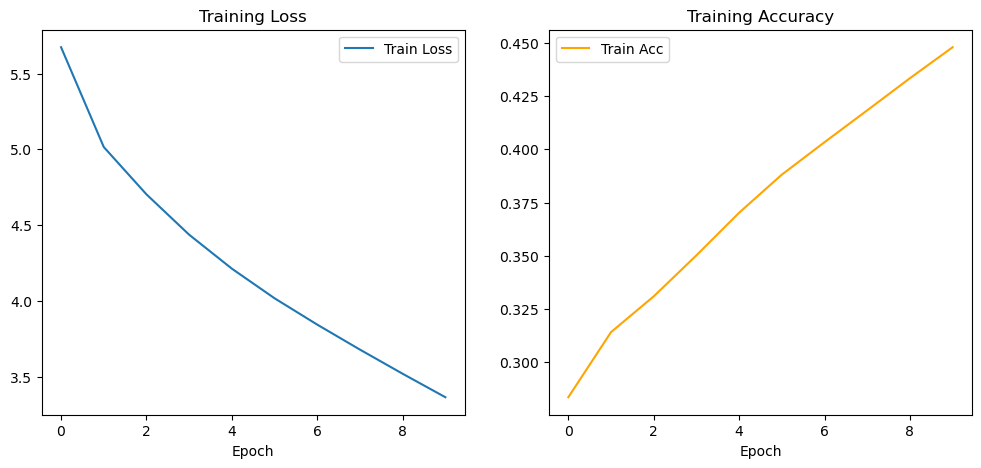

In [7]:
# 손실 함수 및 최적화 도구 설정
criterion = nn.CrossEntropyLoss(ignore_index=vocab[PAD_TOKEN])
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 데이터로더 생성 (간단하게 배치 구성)
dataset = torch.utils.data.TensorDataset(input_ids)
loader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

history = {'loss': [], 'acc': []}

print("--- [과제 조건 3] 사전 학습(Pre-training) 시작 ---")
for epoch in range(EPOCHS):
    epoch_loss = 0
    correct = 0
    total = 0
    
    model.train()
    for batch in loader:
        optimizer.zero_grad()
        inputs = batch[0].to(device)
        
        # [중요] GPT 학습 타겟: 입력 시퀀스를 한 칸씩 밀어서 설정
        # inputs: [<s>, A, B, C] -> targets: [A, B, C, <e>]
        outputs, _ = model(inputs)
        
        # 출력과 타겟의 차원을 맞춤 (Next Token Prediction)
        logits = outputs[:, :-1, :].contiguous().view(-1, VOCAB_SIZE)
        targets = inputs[:, 1:].contiguous().view(-1)
        
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        # 정확도 계산 (패딩 제외)
        _, predicted = torch.max(logits, 1)
        mask = targets != vocab[PAD_TOKEN]
        correct += (predicted[mask] == targets[mask]).sum().item()
        total += mask.sum().item()

    avg_loss = epoch_loss / len(loader)
    avg_acc = correct / total
    history['loss'].append(avg_loss)
    history['acc'].append(avg_acc)
    
    if (epoch + 1) % 1 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {avg_loss:.4f}, Acc: {avg_acc:.4f}")

# [과제 조건 7] Train Loss/Accuracy 그래프 시각화
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['acc'], label='Train Acc', color='orange')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

## Greedy Search 문장 생성 및 어텐션 맵 시각화

- Greedy Search 방식을 사용하여 텍스트를 생성한다.
- 생성된 문장에 대해 모델의 Self-Attention 가중치를 히트맵으로 그려, GPT가 미래 토큰을 보지 않고 이전 토큰들에만 집중하고 있는지 시각적으로 확인한다.


--- [과제 조건 4, 5, 6] Greedy Search 생성 결과 ---
입력 문장: <s> 12시
생성 문장: <s> <p> <unused0> 많이 힘든가봅니다.

--- [과제 조건 8] 어텐션 맵 시각화 (Index 기준) ---


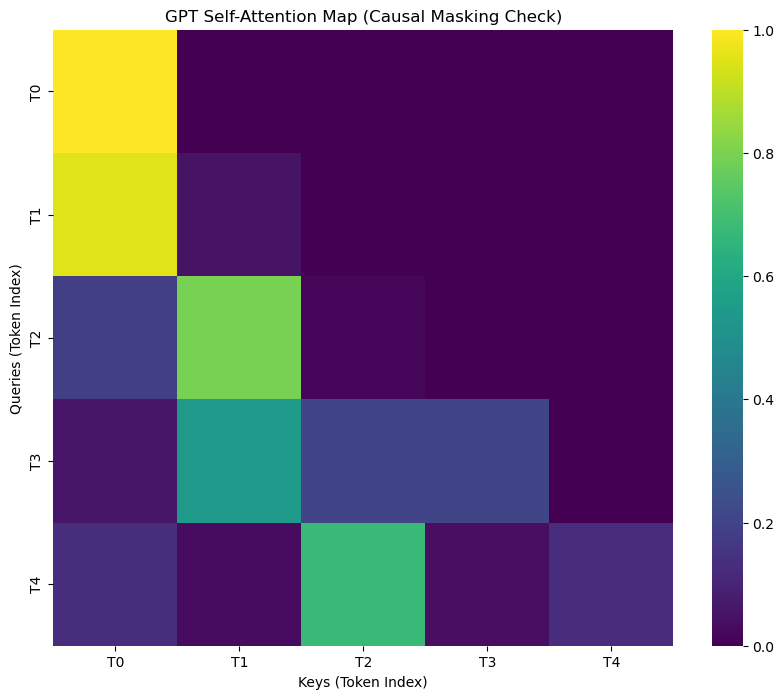

In [12]:
def generate_greedy(model, start_str, vocab, inv_vocab, max_len=20):
    model.eval()
    
    # 시작 문자열 토큰화
    tokens = [vocab.get(w, vocab[PAD_TOKEN]) for w in start_str.split()]
    input_tensor = torch.LongTensor(tokens).unsqueeze(0).to(device)
    
    generated = tokens
    
    with torch.no_grad():
        for _ in range(max_len):
            # [과제 조건 4, 6] GPT 모델을 통한 로짓 생성
            logits, attentions = model(input_tensor)
            
            # 마지막 타임스텝에서 가장 확률이 높은 토큰 선택 (Greedy Search)
            next_token = torch.argmax(logits[:, -1, :], dim=-1).item()
            
            # 종료 토큰을 만나면 생성 중지
            if next_token == vocab[EOS_TOKEN]:
                break
                
            generated.append(next_token)
            
            # 생성된 토큰을 입력에 추가 (Autoregressive)
            new_token_tensor = torch.LongTensor([[next_token]]).to(device)
            input_tensor = torch.cat([input_tensor, new_token_tensor], dim=1)
            
            if input_tensor.size(1) >= PRE_MAX_LEN:
                break
                
    # 토큰 인덱스를 다시 단어로 변환
    sentence = [inv_vocab.get(t, PAD_TOKEN) for t in generated]
    return " ".join(sentence), attentions

# [과제 조건 8] 어텐션 맵 시각화 함수 (인덱스 버전)
def plot_attention_map(attention, tokens):
    # 첫 번째 레이어, 첫 번째 헤드의 어텐션 가중치 추출
    # attention shape: (batch, n_heads, seq_len, seq_len)
    attn_data = attention[0][0, 0, :, :].cpu().detach().numpy()
    
    plt.figure(figsize=(10, 8))
    
    # 한글 폰트 깨짐 방지를 위해 토큰 인덱스(T0, T1...) 사용
    token_indices = [f"T{i}" for i in range(len(tokens))] 
    
    sns.heatmap(attn_data, xticklabels=token_indices, yticklabels=token_indices, 
                annot=False, cmap='viridis')
    
    plt.title("GPT Self-Attention Map (Causal Masking Check)")
    plt.xlabel("Keys (Token Index)")
    plt.ylabel("Queries (Token Index)")
    plt.show()

# --- [과제 조건 4, 5, 6] 실행 및 결과 확인 ---
test_input = "<s> 12시" # 실제 데이터에 존재하는 키워드로 테스트
generated_sentence, last_attentions = generate_greedy(model, test_input, vocab, inv_vocab)

print("\n" + "="*50)
print("--- [과제 조건 4, 5, 6] Greedy Search 생성 결과 ---")
print(f"입력 문장: {test_input}")
print(f"생성 문장: {generated_sentence}")
print("="*50)

# [과제 조건 8] 어텐션 맵 시각화 호출
print("\n--- [과제 조건 8] 어텐션 맵 시각화 (Index 기준) ---")
tokens_list = generated_sentence.split()
plot_attention_map(last_attentions, tokens_list)

**작동 원리:**
1. "`<s>` 12시" 입력 → 모델이 다음에 올 단어들의 확률을 계산 → `<p>`가 당첨.
2. "`<s>` 12시 `<p>`" 입력 → 다음 단어 확률 계산 → `<unused0>`가 당첨. <br>
...<br>
이 과정을 `<e>`(종료 토큰)가 나올 때까지 반복하며 한 단어씩 덧붙이는 자기 회귀(Autoregressive) 방식으로 작동하고 있음.<br>
<br>

- 지금 적절하게 작동하고 있는가? <br>
GPT는 앞의 단어를 보고 다음 단어를 예측한다.
`<s>`와 `<p>`(패딩 or 알 수 없는 단어)를 보고 나서, 질문과 답변의 경계선인 `<unused0>`(구분자)를 정확한 타이밍에 뱉어냄. <br>
이는 모델이 이제 답변을 시작할 차례라는 것을 학습했다는 뜻이다. <br>

- 왜 `<p>`를 내뱉는가? <br>
모델은 단어를 내뱉을 때 지금까지 본 단어들 뒤에는 이 단어가 올 확률이 가장 높다고 판단하는 그 단어를 내뱉는다.<br>
데이터셋에서 많이 보았던 `<p>`를 놓는 것이 모델 입장에서 loss를 줄이는 안전한 선택이라고 판단한 것.

- "많이 힘든가봅니다."가 나온 이유 : <br>
    비록 입력값이 짧았음에도 불구하고, 모델은 자신이 배운 확률 분포 안에서 모델 입장에서는 가장 적절한 대답을 낸 것.

## 단계별 출력 결과 확인

In [13]:
# [확인용 코드] 단계별 데이터 변환 과정 출력

def trace_preprocessing_step(sample_idx=0):
    print(f"=== [Step 1] 원본 텍스트 (Traversal-style) ===")
    sample_text = combined_data[sample_idx]
    print(sample_text)
    
    print(f"\n=== [Step 2] 토큰화 결과 (Token -> ID) ===")
    sample_ids = input_ids[sample_idx]
    # 패딩을 제외한 실제 토큰들만 보기
    valid_ids = [tid.item() for tid in sample_ids if tid != vocab[PAD_TOKEN]]
    print(f"Tokens: {[inv_vocab[tid] for tid in valid_ids]}")
    print(f"IDs   : {valid_ids}")
    
    print(f"\n=== [Step 3] 임베딩 레이어 통과 (ID -> Vector) ===")
    model.eval()
    with torch.no_grad():
        # 임베딩 레이어에서 값 추출
        test_input = input_ids[sample_idx].unsqueeze(0).to(device)
        token_embedded = model.token_emb(test_input)
        pos_indices = torch.arange(test_input.size(1)).unsqueeze(0).to(device)
        pos_embedded = model.pos_emb(pos_indices)
        
        final_embedded = token_embedded + pos_embedded
        
    print(f"Token Embedding Shape: {token_embedded.shape} (Batch, Seq, D_Model)")
    print(f"첫 번째 단어('{inv_vocab[valid_ids[0]]}')의 최종 벡터(일부):")
    print(final_embedded[0, 0, :10].cpu().numpy(), "...") # 앞의 10개 요소만 출력

# 실행
trace_preprocessing_step(0)

=== [Step 1] 원본 텍스트 (Traversal-style) ===
<s> 12시 땡! <unused0> 하루가 또 가네요. <e>

=== [Step 2] 토큰화 결과 (Token -> ID) ===
Tokens: ['<s>', '<unused0>', '하루가', '또', '<e>']
IDs   : [1, 3, 2410, 45, 2]

=== [Step 3] 임베딩 레이어 통과 (ID -> Vector) ===
Token Embedding Shape: torch.Size([1, 50, 512]) (Batch, Seq, D_Model)
첫 번째 단어('<s>')의 최종 벡터(일부):
[ 1.3193996   0.06029177 -1.7795963   0.9429957  -1.986023   -0.06277484
 -0.28884256  0.7941104   1.1299067   0.63449675] ...


<br>

## chatbot 트랜스포머 모델과 GPT-1 모델 구현 비교

| **단계** | **chatbot_4_final.ipynb (기존)** | **GPT-1.ipynb (수정 후)** | **변경 및 제외 사유** |
| --- | --- | --- | --- |
| **데이터 구성** | Q와 A를 분리 (Encoder용 Q, Decoder용 A) | Q와 A를 통합 (하나의 시퀀스) | GPT-1은 Decoder 전용 모델이므로 전체 문장을 한 줄로 읽어야 함 |
| **전처리 방식** | 질문(Q)과 답변(A) 개별 토큰화 및 패딩 | Traversal-style (`<s> Q <unused0> A <e>`) | 여러 입력을 하나의 형태로 통합하여 다음 단어를 예측하는 사전 학습 구조 반영 |
| **데이터 증강** | 별도의 데이터 증강 로직 포함 | 데이터 증강 제외 | 사전 학습(Pre-training)의 원리를 명확히 확인하기 위해 원본 데이터 흐름에 집중 |
| **위치 정보** | 고정된 Positional Encoding (Sine/Cosine) | 학습 가능한 Positional Embedding | GPT-1 논문 규격에 맞춰 데이터로부터 위치 정보를 스스로 학습하도록 변경 |
| **모델 구조** | Encoder-Decoder (Seq2Seq) | Decoder-only (Transformer Decoder) | 인코더를 제거하고 Masked Self-Attention만 사용하여 생성 능력 최적화 |
| **학습 목표** | 분류 또는 정답 생성 (Fine-tuning 성격) | Next Token Prediction (Pre-training) | 특정 태스크 학습 대신 언어 모델링 자체(비지도 학습 원리)에 집중 |

## 회고
과제 제출할 때마다 이거 가능은 한 건가.. 라는 생각을 많이 했다. 그래도 어제 과제 준비하면서 이때까지 알음알음 배웠던 개념들을 코드로 구현하고, 출력 결과들을 보면서 <br>
이게 이걸 말하는 거였구나, 이런 식으로 나오는구나, 이렇게 흐름이 진행되었어야 했구나.. 등을 조금씩 체감했고, 오늘 GPT-1 구현할 때에도 서로 비교하면서 공부할 수 있었다. <br>
어제 선풍기 씻으려고 해체하고 조립했던 게 생각났다. 실제 부품 조립하듯이, 코드를 부품이라 생각하고 필요한 거 넣고 새로운 아이디어 부품을 추가하고, 뺄 건 빼고, 각 부품이 잘 돌기 위해서 중간에 어떻게 연결해야 하는 등.. 두 모델?을 비교하다보니까 더 와닿았던 것 같다. <br>
확실히 기준이 될만한 모범 코드, 모범 설계도를 잘 이해하고 기억하고 있어야 새로운 걸 배울 때에도 빠르게 습득할 수 있다는 점을 느꼈다. <br>
아직 코드의 진행 방향을 스스로 읽고 이해할 수 있기에는 실력이 턱없이 부족하지만, 적어도 개념과 구조를 제대로 알고 있다면 ai에게 구체적으로 이렇게 설계해달라고 요청하기도 수월하고, 에러도 적게 나오는 것 같다. ai와 티키타카를 잘 하는 노력도 많이 필요하다는 것을 배웠다.